<a href="https://colab.research.google.com/github/marsznatalia/PodstawyUczeniaMaszynowego/blob/Class3/pum4_regresja_POPRAWIONA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

zaczytanie niezbędnych bibliotek

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, HuberRegressor, RANSACRegressor, TheilSenRegressor, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn.preprocessing import StandardScaler

zaczytaj dane dotyczace sprzedazy

In [ ]:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Salary Data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rkiattisak/salaly-prediction-for-beginer",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

<ipython-input-21-72cc2aa30810>:9: DeprecationWarning: load_dataset is deprecated and will be removed in future version.
  df = kagglehub.load_dataset(


First 5 records:     Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


preprocessing

1.   sprawdż typy danych
2.   zmien etykiedy na zmienne liczbowe
3. w przypadku brakujacych danych uzupelnij (w przypadku etykiet) najczesciej wystepującą wartością lub średnią wartością



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Gender               375 non-null    int64  
 1   Education Level      375 non-null    int64  
 2   Job Title            375 non-null    int64  
 3   Years of Experience  375 non-null    float64
 4   Salary               375 non-null    float64
dtypes: float64(2), int64(3)
memory usage: 14.8 KB


In [ ]:
le = LabelEncoder()

for column in ['Gender', 'Education Level', 'Job Title']:
  if column in df.columns:
    df[column] = le.fit_transform(df[column])

print(df.head())


   Gender  Education Level  Job Title  Years of Experience    Salary
0       1                0        159                  5.0   90000.0
1       0                1         17                  3.0   65000.0
2       1                2        130                 15.0  150000.0
3       0                0        101                  7.0   60000.0
4       1                1         22                 20.0  200000.0


In [ ]:
df.dropna(inplace=True)
y = df['Salary']
X = df.drop('Salary', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Podziel zbiór danych na testowy i treningowy w stosunku 30/70

Stworz model regresji liniowej korzystajac z parametrów domyślnych
Przykład dokumentacji: https://scikit-learn.org/stable/auto_examples/linear_model/plot_ols.html#sphx-glr-auto-examples-linear-model-plot-ols-py

In [ ]:
regressor = LinearRegression().fit(X_train, y_train)
y_pred = regressor.predict(X_test)

In [ ]:
print(f"Mean squared error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Coefficient of determination: {r2_score(y_test, y_pred):.2f}")

Mean squared error: 254144787.00
Coefficient of determination: 0.88


ocen model na zbiorze testowym za pomocą miar: średni błąd kwadratowy, średni błąd absolutny, wynik wyjaśnionej wariancji

In [ ]:
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")

mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

evs = explained_variance_score(y_test, y_pred)
print(f"Explained Variance Score: {evs:.2f}")

Mean Squared Error (MSE): 254144787.00
Mean Absolute Error (MAE): 11149.73
Explained Variance Score: 0.88


spróbuj poprawić model, zacznij od danych, sprawdz korelacje, znormalizuj

In [ ]:
correlation_matrix = df.corr()

print(correlation_matrix)

                       Gender  Education Level  Job Title  \
Gender               1.000000         0.008677   0.041562   
Education Level      0.008677         1.000000   0.127791   
Job Title            0.041562         0.127791   1.000000   
Years of Experience -0.016055         0.549514   0.087217   
Salary               0.049872         0.625686   0.122487   

                     Years of Experience    Salary  
Gender                         -0.016055  0.049872  
Education Level                 0.549514  0.625686  
Job Title                       0.087217  0.122487  
Years of Experience             1.000000  0.930904  
Salary                          0.930904  1.000000  


In [ ]:
X_train.drop('Age', axis=1, inplace=True)
X_test.drop('Age', axis=1, inplace=True)

KeyError: "['Age'] not found in axis"

In [ ]:
df.head()
X_train.head()
X_test.head()

,Gender,Education Level,Job Title,Years of Experience
167,1,2,147,18.0
33,0,0,84,10.0
15,1,0,89,16.0
316,0,1,117,6.0
57,1,2,116,17.0


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
regressorLscaled = LinearRegression().fit(X_train, y_train)
print(f"Współczynniki: {regressorLscaled.coef_}")
y_predLscaled = regressorLscaled.predict(X_test)
print(f"Średni błąd kwadratowy: {mean_squared_error(y_test, y_predLscaled):.2f}")
print(f"Średni błąd absolutny: {mean_absolute_error(y_test, y_predLscaled):.2f}")
print(f"Wyjaśniona wariancja: {explained_variance_score(y_test, y_predLscaled):.2f}")

Współczynniki: [ 2346.13623915  9140.5074707   1636.53976193 40002.32951143]
Średni błąd kwadratowy: 254144787.00
Średni błąd absolutny: 11149.73
Wyjaśniona wariancja: 0.88


Zbuduj model regresji odpornej i przetestuj jego predykcje

In [ ]:
regressorHuber = HuberRegressor().fit(X_train, y_train)
print(f"Współczynniki: {regressorHuber.coef_}")
y_predHuber = regressorHuber.predict(X_test)
print(f"Średni błąd kwadratowy: {mean_squared_error(y_test, y_predHuber):.2f}")
print(f"Średni błąd absolutny: {mean_absolute_error(y_test, y_predHuber):.2f}")
print(f"Wyjaśniona wariancja: {explained_variance_score(y_test, y_predHuber):.2f}")

Współczynniki: [ 2190.90875997  7231.75552756  2609.78759503 41692.45185436]
Średni błąd kwadratowy: 246067431.35
Średni błąd absolutny: 11022.07
Wyjaśniona wariancja: 0.89


Wykreś przewidziane i faktyczne wartości obu modeli (przykład w dokumentacji: https://scikit-learn.org/stable/auto_examples/ensemble/plot_voting_regressor.html#sphx-glr-auto-examples-ensemble-plot-voting-regressor-py)

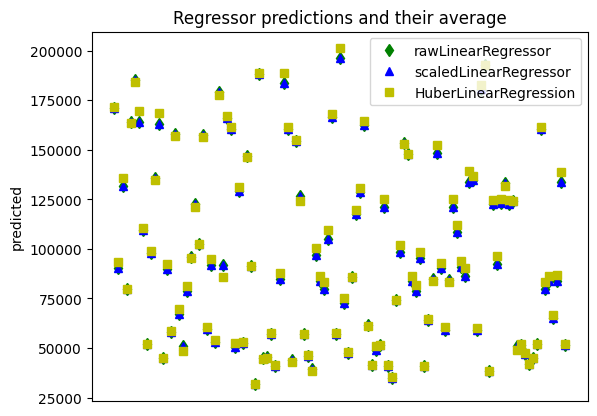

In [ ]:
plt.figure()
plt.plot(y_pred, "gd", label="rawLinearRegressor")
plt.plot(y_predLscaled, "b^", label="scaledLinearRegressor")
plt.plot(y_predHuber, "ys", label="HuberLinearRegression")

plt.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
plt.ylabel("predicted")
plt.legend(loc="best")
plt.title("Regressor predictions and their average")

plt.show()

Zmodyfikuj kod, zeby zwizualizować wynik lepszego z modeli

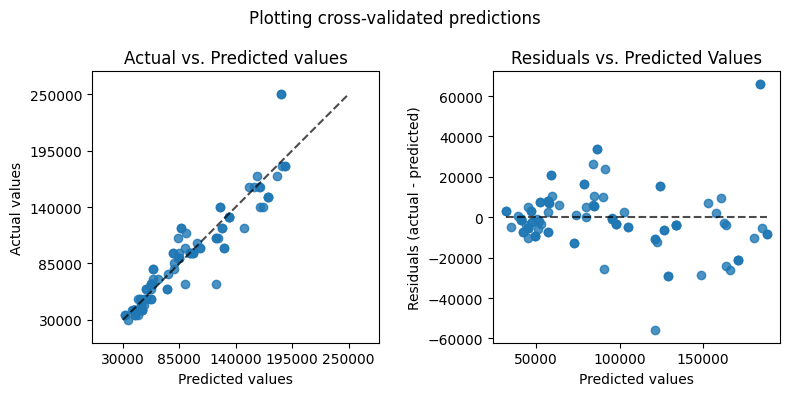

In [ ]:
from sklearn.metrics import PredictionErrorDisplay

fig, axs = plt.subplots(ncols=2, figsize=(8, 4))
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred=y_pred,
    kind="actual_vs_predicted",
    subsample=100,
    ax=axs[0],
    random_state=0,
)
axs[0].set_title("Actual vs. Predicted values")
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred=y_pred,
    kind="residual_vs_predicted",
    subsample=100,
    ax=axs[1],
    random_state=0,
)
axs[1].set_title("Residuals vs. Predicted Values")
fig.suptitle("Plotting cross-validated predictions")
plt.tight_layout()
plt.show()

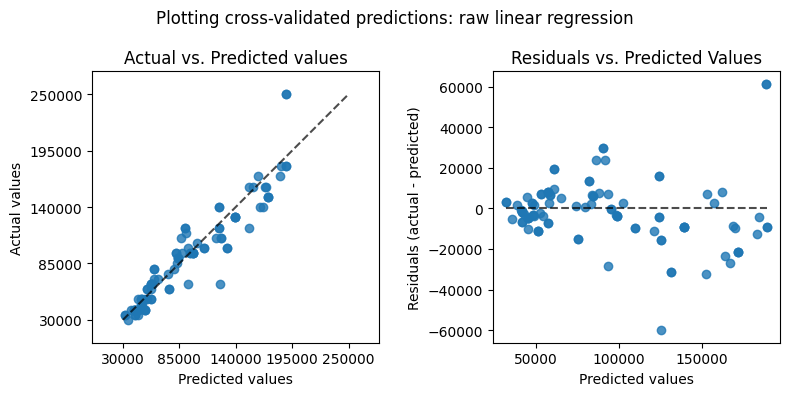

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(8, 4))
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred=y_predHuber,
    kind="actual_vs_predicted",
    subsample=100,
    ax=axs[0],
    random_state=0,
)
axs[0].set_title("Actual vs. Predicted values")
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred=y_predHuber,
    kind="residual_vs_predicted",
    subsample=100,
    ax=axs[1],
    random_state=0,
)
axs[1].set_title("Residuals vs. Predicted Values")
fig.suptitle("Plotting cross-validated predictions: raw linear regression")
plt.tight_layout()
plt.show()